In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.spatial.distance import cdist

from src import config
from src.dataset import BioHubDataset
from src.detector import CellDetector


In [ ]:
DATASET = BioHubDataset(config.DATASET_PATH)

DATASET.info()

sample = DATASET.train_samples[0]

volume = DATASET.load_volume(sample)

print(volume.shape)


In [ ]:
detector = CellDetector(
    sigma=config.GAUSSIAN_SIGMA,
    threshold_abs=config.DETECTION_THRESHOLD,
    min_distance=config.CELL_RADIUS,
)


In [ ]:
frame = np.asarray(volume[0])

mip = frame.max(axis=0)

cells = detector.detect(mip)

print(cells.shape)
print(cells[:10])


In [ ]:
detections = detector.detect_volume(volume)

for t, coords in enumerate(detections):
    print(f"Frame {t:3d}: {len(coords):3d} cells")


In [7]:
previous = detections[0]
current = detections[1]

distances = cdist(previous, current)

print(distances.shape)

(14, 11)


In [8]:
matches = distances.argmin(axis=1)

print(matches[:20])

[ 2  1  4  0  3  0  5  7 10  0  4  8  0  6]


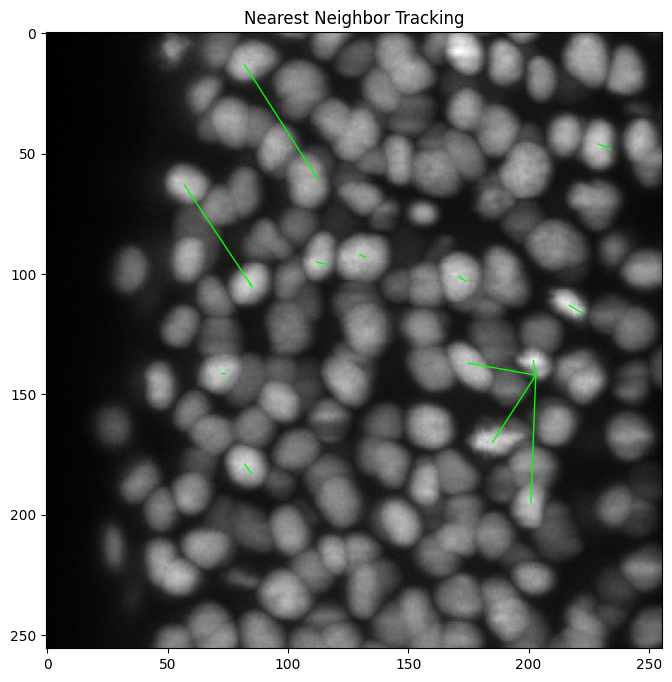

In [9]:
plt.figure(figsize=(8,8))

plt.imshow(np.asarray(volume[0]).max(axis=0), cmap="gray")

for i, j in enumerate(matches):

    p1 = previous[i]
    p2 = current[j]

    plt.plot(
    [p1[1], p2[1]],   # x
    [p1[0], p2[0]],   # y
    color="lime",
    linewidth=1
)

plt.title("Nearest Neighbor Tracking")
plt.show()